In [41]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import requests
import seaborn as sns
import statistics
import traceback

import plotly.figure_factory as ff
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import classification_report

# 1. Загрузим файл HR.csv в pandas dataframe

In [4]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/HR.csv')
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


# 2.Рассчитаем основные статистики для переменных

In [5]:
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [9]:
import traceback
column_stat={}
column_data=['satisfaction_level',
             'last_evaluation',
             'number_project',
             'average_montly_hours',
             'time_spend_company',
             'Work_accident',
             'left',
             'promotion_last_5years',
             'salary'
            ]
index_data=[]
mean_data=[]
median_data=[]
mode_data=[]
max_data=[]
min_data=[]
pstdev_data=[]
for name in column_data:
    if df[name].dtypes!=object:
        index_data.append(name)
        mean_data.append(statistics.mean(df[name]))
        median_data.append(statistics.median(df[name]))
        try:
            mode_data.append(statistics.mode(df[name]))
        except:
            check={}
            for i in df[name]:
                if i not in check:
                    check[i] = 1
                else:
                    check[i] += 1
            maxp = 0
            mode_duration = None
            for k, v in check.items():
                if maxp < v:
                    maxp = v
                    mode_duration = k
            mode_data.append(mode_duration)
        max_data.append(max(df[name]))
        min_data.append(min(df[name]))
        pstdev_data.append(statistics.pstdev(df[name]))
column_stat.setdefault('mean', mean_data)
column_stat.setdefault('median', median_data)
column_stat.setdefault('mode', mode_data)
column_stat.setdefault('max', max_data)
column_stat.setdefault('min', min_data)
column_stat.setdefault('pstdev', pstdev_data)
print(column_stat)

{'mean': [0.6128335222348157, 0.7161017401160077, 3.80305353690246, 201.0503366891126, 3.498233215547703, 0.1446096406427095, 0.2380825388359224, 0.021268084538969265], 'median': [0.64, 0.72, 4, 200, 3, 0, 0, 0], 'mode': [0.1, 0.55, 4, 135, 3, 0, 0, 0], 'max': [1.0, 1.0, 7, 310, 10, 1, 1, 1], 'min': [0.09, 0.36, 2, 96, 2, 0, 0, 0], 'pstdev': [0.2486223626820733, 0.1711634045107436, 1.2325512654823438, 49.94143446256218, 1.4600875552715111, 0.3517068274513532, 0.425909900727095, 0.14427665479561314]}


In [10]:
stat_frame=pd.DataFrame(column_stat, index=index_data)
stat_frame

,mean,median,mode,max,min,pstdev
satisfaction_level,0.612834,0.64,0.10,1.0,0.09,0.248622
last_evaluation,0.716102,0.72,0.55,1.0,0.36,0.171163
number_project,3.803054,4.00,4.00,7.0,2.00,1.232551
average_montly_hours,201.050337,200.00,135.00,310.0,96.00,49.941434
time_spend_company,3.498233,3.00,3.00,10.0,2.00,1.460088
Work_accident,0.144610,0.00,0.00,1.0,0.00,0.351707
left,0.238083,0.00,0.00,1.0,0.00,0.425910
promotion_last_5years,0.021268,0.00,0.00,1.0,0.00,0.144277


# Рассчитаем и визуализируем корреляционную матрицу для количественных переменных. Определим две самые скоррелированные и две наименее скоррелированные переменные.

In [11]:
df.iloc[:,:5].corr().round(3)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company
satisfaction_level,1.000,0.105,-0.143,-0.020,-0.101
last_evaluation,0.105,1.000,0.349,0.340,0.132
number_project,-0.143,0.349,1.000,0.417,0.197
average_montly_hours,-0.020,0.340,0.417,1.000,0.128
time_spend_company,-0.101,0.132,0.197,0.128,1.000


In [15]:
df_corrs = df[['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company']].corr()

fig = ff.create_annotated_heatmap(z=df_corrs.values, x=list(df_corrs.index),
                                  y=list(df_corrs.columns),
                                  annotation_text=df_corrs.round(3).values,
                                  showscale=True, colorscale='tropic')
fig.show()



*   Наиболее скореллированные переменные: average_montly_hours и number_project: 0.417
*   Наименее скоррелированные переменные number_project и satisfaction_level: -0.143





# 4. Рассчитаем сколько сотрудников работает в каждом департаменте

In [16]:
df.groupby('department').size()

,0
department,
IT,1227
RandD,787
accounting,767
hr,739
management,630
marketing,858
product_mng,902
sales,4140
support,2229


# 5. Покажем распределение сотрудников по зарплатам

In [17]:
df.salary.value_counts()

,count
salary,
low,7316
medium,6446
high,1237


# 6. Покажем распределение сотрудников по зарплатам в каждом департаменте по отдельности

In [18]:
df.pivot_table(index='department', columns='salary', aggfunc='size')

salary,high,low,medium
department,,,
IT,83,609,535
RandD,51,364,372
accounting,74,358,335
hr,45,335,359
management,225,180,225
marketing,80,402,376
product_mng,68,451,383
sales,269,2099,1772
support,141,1146,942


# 7. Проверим гипотезу, что сотрудники с высоким окладом проводят на работе больше времени, чем сотрудники с низким окладом

**Гипотеза**

H0 - в среднем проведенное на работе время одинаково для всех работников

<Axes: xlabel='salary', ylabel='average_montly_hours'>

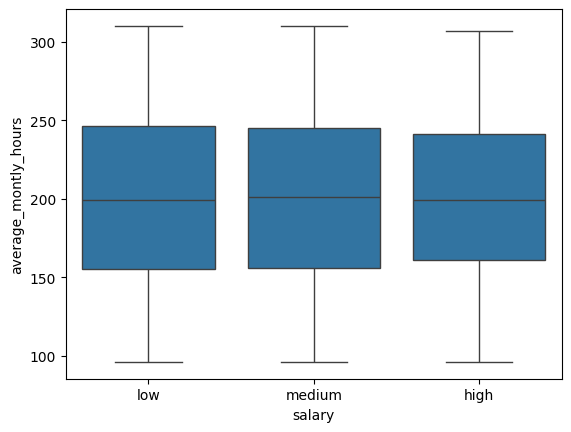

In [21]:
sns.boxplot(x='salary', y='average_montly_hours', data=df)

In [22]:
salary_low = df[df['salary'] == 'low']['average_montly_hours']
salary_high = df[df['salary'] == 'high']['average_montly_hours']

In [23]:
result = stats.ttest_ind(salary_low, salary_high, equal_var=False)

a = 0.05

if (result.pvalue < a):
    print('Отвергаем нулевую гипотезу')
else:
    print('Не отвергаем нулевую гипотезу')

Не отвергаем нулевую гипотезу


H0 верна - в среднем проведённое на работе время одинаково для всех работников.

# 8. Рассчитаем показатели среди уволившихся и не уволившихся сотрудников (по отдельности):



*   Доля сотрудников с повышением за последние 5 лет
*   Средняя степень удовлетворенности
*   Среднее количество проектов


In [24]:
workers = df[(df['left'] == 0)]
ex_workers =  df[(df['left'] == 1)]

In [25]:
indicators = pd.DataFrame()
rows = []

rows.append(
    {
    'Показатель': 'Доля получивших повышение',
    'Уволившиеся': round(ex_workers.promotion_last_5years.value_counts(normalize=True)[1], 3),
    'Действующие': round(workers.promotion_last_5years.value_counts(normalize=True)[1], 3)
    }
)

rows.append(
    {
    'Показатель': 'Средняя степень удовлетворенности',
    'Уволившиеся': round(ex_workers.satisfaction_level.mean(), 3),
    'Действующие': round(workers.satisfaction_level.mean(), 3)
    }
)

rows.append(
    {
    'Показатель': 'Среднее количество проектов',
    'Уволившиеся': round(ex_workers.number_project.mean(), 3),
    'Действующие': round(workers.number_project.mean(), 3)
    }
)

for row in rows:
    indicators = pd.concat([indicators, pd.DataFrame([row])])

indicators

,Показатель,Уволившиеся,Действующие
0,Доля получивших повышение,0.005,0.026
0,Средняя степень удовлетворенности,0.440,0.667
0,Среднее количество проектов,3.856,3.787


# 9. Разделим данные на тестовую и обучающую выборки. Построим модель LDA, предсказывающую уволился ли сотрудник на основе имеющихся факторов (кроме department и salary). Оценим качество модели на тестовой выборке

In [26]:
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=['left','department','salary']), df['left'] , test_size=0.2)

In [27]:
model = LinearDiscriminantAnalysis()
model.fit_transform(X_train,y_train)

array([[ 0.12676586],
       [-0.93109796],
       [ 0.71264211],
       ...,
       [-0.27435162],
       [-0.5298277 ],
       [-0.87886294]])

In [37]:
y_pred = model.predict(X_test)

In [36]:
model.score(X_test, y_test)

0.7616666666666667

In [42]:
print(classification_report(y_true=y_test,
                                y_pred=y_pred,
                                target_names=["Stay", "Leave"]))

              precision    recall  f1-score   support

        Stay       0.80      0.91      0.85      2295
       Leave       0.49      0.27      0.34       705

    accuracy                           0.76      3000
   macro avg       0.64      0.59      0.60      3000
weighted avg       0.73      0.76      0.73      3000



Взвешенные значения precision: 0.73; recall: 0.76.
Модель предсказывает людей, которые останутся лучше, чем тех, кто уволится (f1-score 0.85 против 0.34 соответственно)

# 10. Загрузить jupyter notebook с решение на github и прислать ссылку

**https://github.com/ikukarin/pyda_homeworks/blob/main/diplom_kukarin.ipynb**